In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

In [2]:
orders = pd.read_csv(r"C:\Users\Kandie\Downloads\orders.csv")     

In [3]:
order_details = pd.read_csv(r"C:\Users\Kandie\Downloads\order_details.csv")

In [4]:
pizzas = pd.read_csv(r"C:\Users\Kandie\Downloads\pizzas.csv")

In [5]:
pizza_types = pd.read_csv(r"C:\Users\Kandie\Downloads\pizza_types.csv", encoding="latin1")

In [6]:
#join the 4 csv files into a single data frame
df = order_details.merge(orders, on='order_id', how='left')     

In [7]:
df = df.merge(pizzas, on='pizza_id', how='left')  

In [8]:
df = df.merge(pizza_types, on='pizza_type_id', how='left')

In [9]:
df.head()

,order_details_id,order_id,pizza_id,quantity,date,time,pizza_type_id,size,price,name,category,ingredients
0,1,1,hawaiian_m,1,2015-01-01,11:38:36,hawaiian,M,13.25,The Hawaiian Pizza,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese"
1,2,2,classic_dlx_m,1,2015-01-01,11:57:40,classic_dlx,M,16.00,The Classic Deluxe Pizza,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,..."
2,3,2,five_cheese_l,1,2015-01-01,11:57:40,five_cheese,L,18.50,The Five Cheese Pizza,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go..."
3,4,2,ital_supr_l,1,2015-01-01,11:57:40,ital_supr,L,20.75,The Italian Supreme Pizza,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni..."
4,5,2,mexicana_m,1,2015-01-01,11:57:40,mexicana,M,16.00,The Mexicana Pizza,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O..."


In [10]:
df.sample(5)

,order_details_id,order_id,pizza_id,quantity,date,time,pizza_type_id,size,price,name,category,ingredients
39076,39077,17221,thai_ckn_m,1,2015-10-20,12:35:28,thai_ckn,M,16.75,The Thai Chicken Pizza,Chicken,"Chicken, Pineapple, Tomatoes, Red Peppers, Tha..."
3487,3488,1547,ital_cpcllo_l,1,2015-01-26,20:58:38,ital_cpcllo,L,20.50,The Italian Capocollo Pizza,Classic,"Capocollo, Red Peppers, Tomatoes, Goat Cheese,..."
10115,10116,4426,spicy_ital_s,1,2015-03-16,13:45:41,spicy_ital,S,12.50,The Spicy Italian Pizza,Supreme,"Capocollo, Tomatoes, Goat Cheese, Artichokes, ..."
25844,25845,11374,pep_msh_pep_m,1,2015-07-09,16:56:14,pep_msh_pep,M,14.50,"The Pepperoni, Mushroom, and Peppers Pizza",Classic,"Pepperoni, Mushrooms, Green Peppers"
46108,46109,20246,pep_msh_pep_m,1,2015-12-10,17:15:39,pep_msh_pep,M,14.50,"The Pepperoni, Mushroom, and Peppers Pizza",Classic,"Pepperoni, Mushrooms, Green Peppers"


In [11]:
df.shape

(48620, 12)

In [12]:
df.columns

Index(['order_details_id', 'order_id', 'pizza_id', 'quantity', 'date', 'time',
       'pizza_type_id', 'size', 'price', 'name', 'category', 'ingredients'],
      dtype='object')

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48620 entries, 0 to 48619
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_details_id  48620 non-null  int64  
 1   order_id          48620 non-null  int64  
 2   pizza_id          48620 non-null  object 
 3   quantity          48620 non-null  int64  
 4   date              48620 non-null  object 
 5   time              48620 non-null  object 
 6   pizza_type_id     48620 non-null  object 
 7   size              48620 non-null  object 
 8   price             48620 non-null  float64
 9   name              48620 non-null  object 
 10  category          48620 non-null  object 
 11  ingredients       48620 non-null  object 
dtypes: float64(1), int64(3), object(8)
memory usage: 4.5+ MB


In [14]:
df.isna().sum()

order_details_id    0
order_id            0
pizza_id            0
quantity            0
date                0
time                0
pizza_type_id       0
size                0
price               0
name                0
category            0
ingredients         0
dtype: int64

In [15]:
#checking any lost or duplicate rows
print("order_details rows:", len(order_details))

order_details rows: 48620


In [16]:
print("merged df rows:", len(df))

merged df rows: 48620


In [17]:
#key columns from the 4 tables
df[['order_id', 'pizza_id', 'name', 'size', 'price', 'quantity']].head(10)

,order_id,pizza_id,name,size,price,quantity
0,1,hawaiian_m,The Hawaiian Pizza,M,13.25,1
1,2,classic_dlx_m,The Classic Deluxe Pizza,M,16.00,1
2,2,five_cheese_l,The Five Cheese Pizza,L,18.50,1
3,2,ital_supr_l,The Italian Supreme Pizza,L,20.75,1
4,2,mexicana_m,The Mexicana Pizza,M,16.00,1
5,2,thai_ckn_l,The Thai Chicken Pizza,L,20.75,1
6,3,ital_supr_m,The Italian Supreme Pizza,M,16.50,1
7,3,prsc_argla_l,The Prosciutto and Arugula Pizza,L,20.75,1
8,4,ital_supr_m,The Italian Supreme Pizza,M,16.50,1
9,5,ital_supr_m,The Italian Supreme Pizza,M,16.50,1


In [18]:
#What is the total revenue/sales?
total_revenue = (order_details.merge(pizzas, on='pizza_id')
                  .eval('line_revenue = quantity * price')['line_revenue'].sum())

In [19]:
total_revenue

np.float64(817860.05)

In [20]:
#Find the total quantity sold.
total_quantity = df['quantity'].sum()

In [21]:
total_quantity

np.int64(49574)

In [22]:
#Find the total orders.
total_orders = df['order_id'].nunique()

In [23]:
total_orders

21350

In [24]:
#How many pizza types do they sell?
no_pizza_types = df['pizza_type_id'].nunique()

In [25]:
no_pizza_types

32

In [26]:
#Find the average price of the pizzas.

df['revenue'] = df['quantity'] * df['price']

avg_price_weighted = df['revenue'].sum() / df['quantity'].sum()
avg_price_weighted

np.float64(16.497761931657724)

In [27]:
print(df.columns.tolist())

['order_details_id', 'order_id', 'pizza_id', 'quantity', 'date', 'time', 'pizza_type_id', 'size', 'price', 'name', 'category', 'ingredients', 'revenue']


In [28]:
#What are the peak hours of sales?
df['hour'] = pd.to_datetime(df['time'], format='%H:%M:%S').dt.hour

#Group by hour and aggregate revenue, order count, and quantity
hourly_sales = df.groupby('hour').agg(
    revenue=('revenue', 'sum'),
    orders=('order_id', 'nunique'),
    quantity=('quantity', 'sum')
).reset_index()

hourly_sales_sorted = hourly_sales.sort_values('revenue', ascending=False)  #sort to find the peak

print(hourly_sales_sorted.head(5))

    hour    revenue  orders  quantity
3     12  111877.90    2520      6776
4     13  106065.70    2455      6413
9     18   89296.85    2399      5417
8     17   86237.45    2336      5211
10    19   72628.90    2009      4406


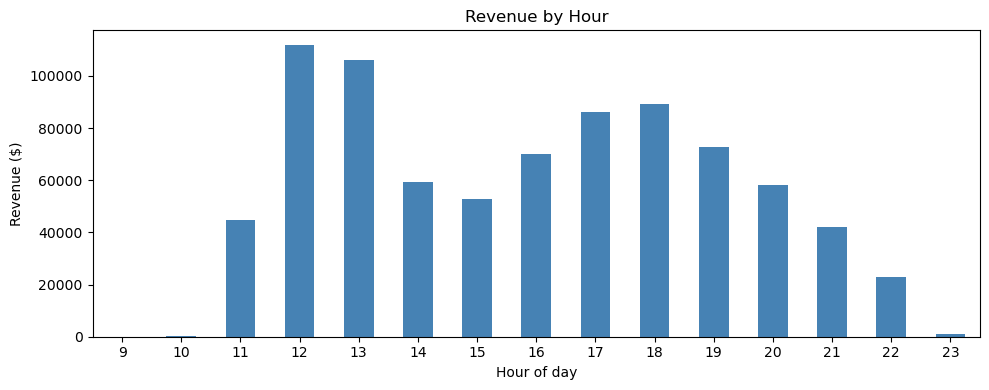

In [29]:
hourly_sales.plot(
    x='hour',
    y='revenue',
    kind='bar',
    figsize=(10, 4),
    title='Revenue by Hour',
    color='steelblue',
    legend=False
)

plt.xlabel('Hour of day')
plt.ylabel('Revenue ($)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [30]:
#Find the total sales made on each day of the week. Which day of the week is when sales are made the most?

# Extract the day name from the date column
df['day_of_week'] = pd.to_datetime(df['date']).dt.day_name()

#Group by day of week and sum revenue
daily_sales = df.groupby('day_of_week')['revenue'].sum()

#Reorder days to show Mon → Sun
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily_sales = daily_sales.reindex(day_order)

print(daily_sales)

day_of_week
Monday       107329.55
Tuesday      114133.80
Wednesday    114408.40
Thursday     123528.50
Friday       136073.90
Saturday     123182.40
Sunday        99203.50
Name: revenue, dtype: float64


In [31]:
#Find the day with the highest sales
busiest_day = daily_sales.idxmax()
print(f"\nBusiest day: {busiest_day} (${daily_sales.max():,.2f})")


Busiest day: Friday ($136,073.90)


In [32]:
#Find the top 5 bestselling pizzas.(by quantity)
top5_pizzas = df.groupby('name')['quantity'].sum().sort_values(ascending=False).head(5)  #group by pizza name & sum quantity sold

top5_pizzas

name
The Classic Deluxe Pizza      2453
The Barbecue Chicken Pizza    2432
The Hawaiian Pizza            2422
The Pepperoni Pizza           2418
The Thai Chicken Pizza        2371
Name: quantity, dtype: int64

In [33]:
#bestselling by revenue
top5_by_revenue = df.groupby('name')['revenue'].sum().sort_values(ascending=False).head(5)

top5_by_revenue

name
The Thai Chicken Pizza          43434.25
The Barbecue Chicken Pizza      42768.00
The California Chicken Pizza    41409.50
The Classic Deluxe Pizza        38180.50
The Spicy Italian Pizza         34831.25
Name: revenue, dtype: float64

In [34]:
#Find the sales made in each month. Any trend noticeable?
df['month'] = pd.to_datetime(df['date']).dt.month_name() #extract month name from the date column

#Group by month and sum revenue
monthly_sales = df.groupby('month')['revenue'].sum()

#Reorder months to show Jan → Dec 
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']
monthly_sales = monthly_sales.reindex(month_order)
monthly_sales

month
January      69793.30
February     65159.60
March        70397.10
April        68736.80
May          71402.75
June         68230.20
July         72557.90
August       68278.25
September    64180.05
October      64027.60
November     70395.35
December     64701.15
Name: revenue, dtype: float64

- **July**  
  Strongest month ($72,557.90); likely boosted by July 4th, which earlier analysis showed was one of the single highest-revenue days of the year  

- **September and October**  
  Softest months ($64k each)

- **February**  
  Slightly lower as well, likely affected by being the shortest month ($65,159.60)  

In [35]:
#Are there pizza types that are not doing well on the menu?

pizza_performance = df.groupby('name').agg(
    quantity_sold=('quantity', 'sum'),
    revenue=('revenue', 'sum')
).sort_values('quantity_sold')

In [36]:
pizza_performance.head(5)

,quantity_sold,revenue
name,,
The Brie Carre Pizza,490,11588.50
The Mediterranean Pizza,934,15360.50
The Calabrese Pizza,937,15934.25
The Spinach Supreme Pizza,950,15277.75
The Soppressata Pizza,961,16425.75


In [37]:
#checking Brie's size variant
brie = df[df['name'] == 'The Brie Carre Pizza']
print(brie.groupby('size')['quantity'].sum())

size
S    490
Name: quantity, dtype: int64


In [38]:
#check category pattern

print(pizza_performance.merge(pizza_types[['name','category']], on='name').groupby('category')['quantity_sold'].mean())

category
Chicken    1841.666667
Classic    1861.000000
Supreme    1331.888889
Veggie     1294.333333
Name: quantity_sold, dtype: float64


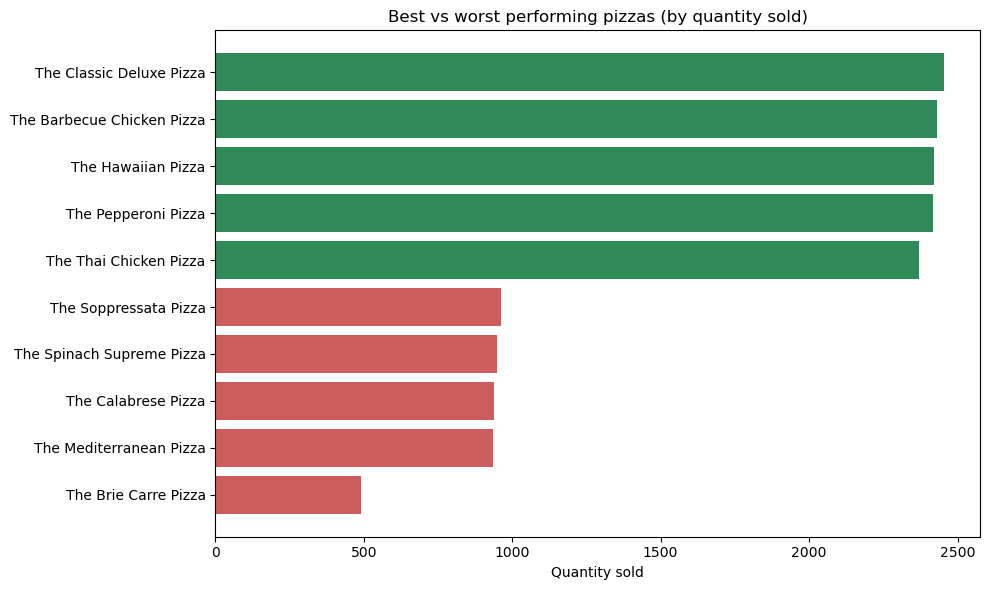

In [39]:
#Pizza perfomance (quantity)
#quantity sold per pizza
pizza_performance = df.groupby('name')['quantity'].sum().sort_values(ascending=False)

#take top 5 and bottom 5
top5 = pizza_performance.head(5)
bottom5 = pizza_performance.tail(5)

#combine into one series for plotting (top 5 first, then bottom 5)
combined = pd.concat([top5, bottom5])

#green for top performers, red for bottom performers
colors = ['seagreen'] * 5 + ['indianred'] * 5

#plot as a horizontal bar chart
plt.figure(figsize=(10, 6))
plt.barh(combined.index, combined.values, color=colors)
plt.xlabel('Quantity sold')
plt.title('Best vs worst performing pizzas (by quantity sold)')
plt.gca().invert_yaxis()   # keeps top seller at the top of the chart
plt.tight_layout()
plt.show()

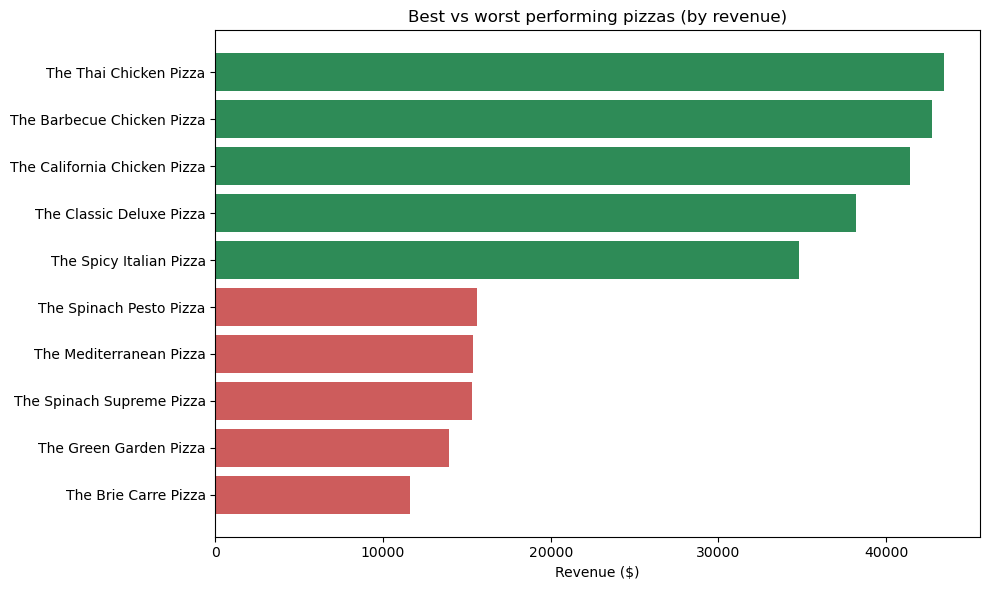

In [41]:
#Pizza perfomance (revenue)
#quantity sold per pizza
pizza_performance = df.groupby('name')['revenue'].sum().sort_values(ascending=False)

#take top 5 and bottom 5
top5 = pizza_performance.head(5)
bottom5 = pizza_performance.tail(5)

#combine into one series for plotting (top 5 first, then bottom 5)
combined = pd.concat([top5, bottom5])

#green for top performers, red for bottom performers
colors = ['seagreen'] * 5 + ['indianred'] * 5

#plot as a horizontal bar chart
plt.figure(figsize=(10, 6))
plt.barh(combined.index, combined.values, color=colors)
plt.xlabel('Revenue ($)')
plt.title('Best vs worst performing pizzas (by revenue)')
plt.gca().invert_yaxis()   # keeps top seller at the top of the chart
plt.tight_layout()
plt.show()

# Insights

## Key Metrics
- **Total revenue:** $817,860.05  
- **Total quantity sold:** 49,574 pizzas  
- **Total orders:** 21,350  
- **Distinct pizza types:** 32 (91 size variants)  
- **Average price per pizza:** $16.01 (menu average) / $16.49 (sales-weighted)  
- **Average order value:** $38.31  
- **Average pizzas per order:** 2.3  

The business generated just over **$817,000** in revenue from **49,574 pizzas** across **21,350 orders** over the year — roughly **58 orders** and **$2,240 in revenue per day**.

## Scale of the Business
- 32 distinct pizza types (91 including size variants)  
- ~49,500 pizzas sold across 21,350 orders in a year  
- Average order value: $38.31  
- Average order size: 2.3 pizzas  
- Customer base leans toward **small, quick orders** rather than large group orders  

## Average Price
- Menu average: $16.01  
- Sales-weighted average: $16.49  
- Customers lean slightly toward **pricier sizes and types**  

## Peak Hours
- **Lunch peak:** 12–1pm (busiest hour, $111,000 revenue)  
- **Dinner peak:** 5–7pm  
- **Quietest period:** 2–4pm  

## Day of Week
- Sales build steadily through the week  
- **Friday:** peak ($136,073.90)  
- **Sunday:** lowest ($99,203.50)  
- Average order value stable (~$37.80–$39.00) → swings driven by **volume, not basket size**  

## Bestselling Pizzas
- **By quantity (≈2,400 units each):** Classic Deluxe, Barbecue Chicken, Hawaiian, Pepperoni, Thai Chicken  
- **By revenue:** Chicken pizzas dominate (Thai Chicken, Barbecue Chicken, California Chicken) due to higher price points  

## Monthly Trend
- Revenue range: $64k–$73k (≈13% swing)  
- **July:** strongest month (boosted by July 4th)  
- **September & October:** softest months  
- Demand is **stable, non-seasonal** → good for staffing & inventory planning  

## Underperforming Pizzas
- **Brie Carre Pizza:** only 490 units sold (clear laggard)  
- Other weak sellers: Green Garden, Spinach Supreme, Mediterranean, Spinach Pesto  
- 3 of bottom 5 are **Veggie category** → suggests recipe-specific issues, not category-wide  

## Next Steps
- **Menu:** Phase out or rework on Brie Carre Pizza  
- **Staffing:** Plan for lunch (12–1pm) and dinner (5–7pm) surges; lighter coverage mid-afternoon  
- **Weekly planning:** Fridays need most capacity; Sundays are natural for lighter staffing or promotions  
- **Sizing strategy:** Large pizzas = most popular & highest-margin → lead with them in menu design/promotions  
- **Seasonality:** Stable year-round demand; only minor July bump → no major seasonal adjustments needed  